# ASTR-154 Final Project - Exoplanet Obliquity Angle
## File: hypothesis_testing
This file contains to code for performing hypothesis testing on two sets of obliquity angle data in order to determine whether they belong to different distributions based on the obliquity angle value and their systems "binarity"

Author: Babak Aryan

In [1]:
from astropy import table
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read in the Exoplanet data generated from the "NASA Exoplanet Archive" database
# This particular list conatins only exoplanets with listed project obliquity values
data_file_loc = '../data/'
exo_file_name = 'NASA-Exoplanet-Archive-20260514.csv'
exo_table = table.Table.read(data_file_loc+exo_file_name, format='ascii.csv', header_start=123)

In [3]:
# Divide the list into two sets, one containing only exoplanets with a singl
# star system ('single_sys'), and the other with 2 or more star systems
# ('binary_sys')
binary_sys = exo_table[exo_table['sy_snum'] >  1]['gaia_dr3_id', 'gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq']
single_sys = exo_table[exo_table['sy_snum'] == 1]['gaia_dr3_id', 'gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq']
print(binary_sys, '\n')
print(single_sys, '\n')


        gaia_dr3_id           gaia_dr3_source_id ... sy_snum pl_projobliq
---------------------------- ------------------- ... ------- ------------
Gaia DR3 4287820848378092672 4287820848378092672 ...       2          4.0
Gaia DR3 3393939030531019520 3393939030531019520 ...       2        -1.47
Gaia DR3 1928431764627661440 1928431764627661440 ...       2          3.7
Gaia DR3 1340497608486742400 1340497608486742400 ...       2        189.1
 Gaia DR3 381592313648387200  381592313648387200 ...       3        -10.0
 Gaia DR3 846946629987527168  846946629987527168 ...       2         -2.1
Gaia DR3 3167323052618369408 3167323052618369408 ...       2         20.0
Gaia DR3 1159336403336463872 1159336403336463872 ...       2         24.2
 Gaia DR3 359058441314838528  359058441314838528 ...       2        -26.0
Gaia DR3 1510191594552968832 1510191594552968832 ...       2         21.2
                         ...                 ... ...     ...          ...
 Gaia DR3 328636019723252096  32863601

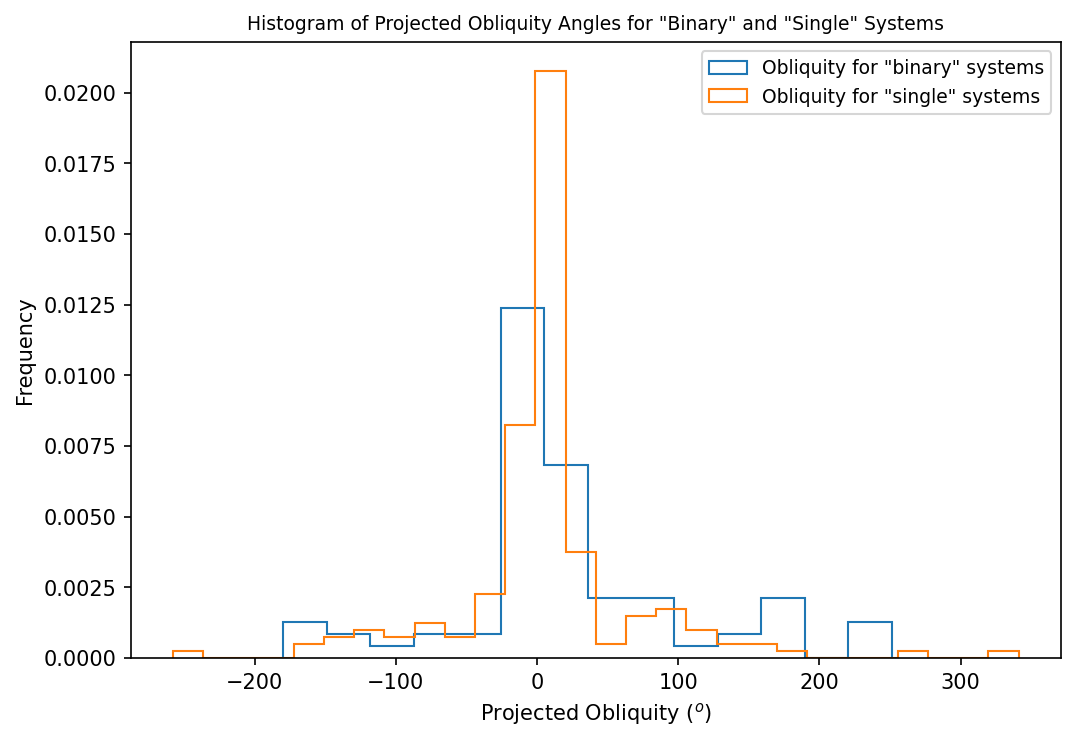

In [4]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.hist(binary_sys['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.hist(single_sys['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.title('Histogram of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('Frequency');
plt.legend(['Obliquity for "binary" systems', 'Obliquity for "single" systems'], fontsize=9, loc=1);

plt.show()

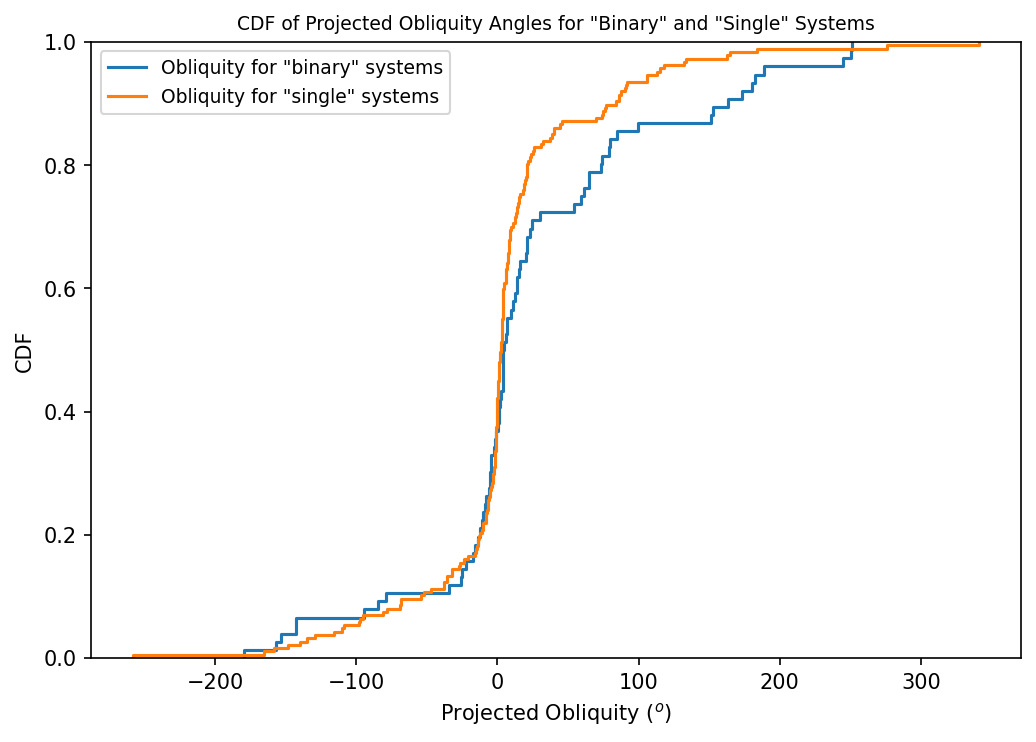

In [5]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.ecdf(binary_sys['pl_projobliq']);
plt.ecdf(single_sys['pl_projobliq']);
plt.title('CDF of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('CDF');
plt.legend(['Obliquity for "binary" systems', 'Obliquity for "single" systems'], fontsize=9, loc=2);

plt.show()

In [6]:
from scipy import stats

In [7]:
# Calculating D and p-value for the 2-sample K-S test on the two datasets
# ('binary_sys' vs. 'single_sys')
ks_d, ks_p = stats.kstest(binary_sys['pl_projobliq'], single_sys['pl_projobliq'])
print(f'K-S D, p-value: {ks_d:0.4f} {ks_p:0.4%}')

K-S D, p-value: 0.1480 16.5913%


In [8]:
# Calculating the D and p-value for k-sample Anderson-Darling (A-D) test
#  on the two datasets ('binary_sys' vs. 'single_sys')
ad = stats.anderson_ksamp([binary_sys['pl_projobliq'], single_sys['pl_projobliq']], variant='midrank', method=stats.PermutationMethod());
print(f'A-D statistics and p-value: {ad.statistic:0.4f} {ad.pvalue:0.4%}')


A-D statistics and p-value: 1.4780 8.0600%


### Gaia Data Retrieval ###

Used the following query to get the Gaia data for the list of exoplanets in our exo_table above:

SELECT * 
FROM gaiaedr3.gaia_source 
WHERE source_id IN (6794047652729201024,
3105507886130792448,
4285511294172309504,
3120058170178779392,
3120002649138831360,
4287820848378092672,
4263427117767106816,
4477340334766250496,
3393939030531019520,
457317534880081152,
1928431764627661440,
2086512227851023872,
2086512227851023872,
1499514786891168640,
1014520826353577088,
1340497608486742400,
179498266829041664,
381592313648387200,
1849786481032616960,
1849786481032616960,
1849786481032616960,
1334573817793362560,
1380825667768742144,
869913435026514688,
770622651659107712,
846946629987527168,
1808938730710633984,
3167323052618369408,
1159336403336463872,
359058441314838528,
1510191594552968832,
1510191594552968832,
3096441729861716224,
356348286886230272,
893550942158776832,
1810218734058821632,
1541532207133249920,
1291120362349158016,
4290415081653653632,
1835842749465226368,
3385777286999240576,
1925321658551399040,
3080104185367102592,
2129256395211984000,
3291455819447952768,
1891507552826485632,
898130030131443584,
6805149288493408640,
3492502001623237888,
3492502001623237888,
6805886373600546176,
5605119586158973440,
3698307419878650240,
3698307419878650240,
2248126315275354496,
2554032474712538880,
2554032474712538880,
2554032474712538880,
875071278432954240,
875071278432954240,
3877070590167177344,
600698184764497664,
600698184764497664,
6113920619134019456,
651907079835937280,
3311804515502788352,
3311804515502788352,
3807826337147474176,
6239702034929248512,
150054788545735424,
6253844468883543680,
6253844468883543680,
665757593450097920,
2881784280929695360,
6710517793025165696,
3761497761876022400,
651935220461650560,
1612165353793791488,
3142847477107193344,
2033123654092592384,
2054523105274216704,
1644692064543192704,
1076970406751899008,
1076970406751899008,
1076970406751899008,
806492023789218688,
727624020367528576,
727624020367528576,
1464700950221781504,
1464700950221781504,
181908842994567936,
2064327278651198336,
2073860662955260416,
2126633166627436928,
2130632159136095104,
2076970047474270208,
2076483616656410496,
2086449761846310784,
2100451630105041152,
2100451630105041152,
2100243616248608896,
2100243616248608896,
2100243616248608896,
2075998903831657472,
2132628489996257920,
2132628489996257920,
2116730994965905280,
2099925719951103872,
1744911763437512064,
1744911763437512064,
5245968236116294016,
5245968236116294016,
2244830490514284928,
3620030644476623616,
1265513389372846848,
995754258812449024,
6715688452614516736,
1726858366624544640,
1677343097418015488,
2241587416547315584,
1675923009431370880,
1675923009431370880,
1675923009431370880,
1978027916667478656,
5723638723350902400,
1651911084230149248,
1428639816392087552,
3719927426253118848,
2259354802894412928,
5489726768531119616,
5388416255319817856,
2296342614570999552,
1490845584382687232,
1344163891352965632,
4641274773980363520,
6828814283414902912,
178924390478792320,
3919169687804622336,
1111639314047794944,
2997312063605005056,
6027376203516634112,
2099011888349441536,
5289275864525400704,
5289275864525400704,
4657949756881138176,
114340658009875072,
3815937670648091392,
2640121486388076032,
430269136520563200,
5580554052549277056,
5313031504751276032,
5313031504751276032,
3607877948613218304,
4665704096987467776,
4683737294569921664,
2993658970584498048,
3010759262610139776,
2974906868489280768,
2635476908753563008,
2635476908753563008,
2635476908753563008,
2098964849867337856,
2131314401800665344,
4609062308806929152,
51886335968692480,
51886335968692480,
2862548428079638912,
4675352109659600000,
4439085988769170432,
3788394461991295488,
3788394461991295488,
3578638842054261248,
3578638842054261248,
3578638842054261248,
123376685084303360,
4746157737910069888,
3435282862461427072,
5565050255701441664,
5565050255701441664,
702295464353437952,
6173451477191225984,
2441013811932929280,
1242084170974175232,
1358355738906114816,
1358355738906114816,
6171009049549197824,
2514360548993901312,
6283723285046532864,
5664957444179338240,
5664957444179338240,
6154982877300947840,
6042793005779654656,
6086712585429729536,
2323985539482908416,
6139403450370668800,
6003809889735481856,
4955371367334610048,
3070964117005132416,
2790691147020786816,
6339097679918871168,
6339097679918871168,
5411736896952029568,
4994237247949280000,
5453063823882876032,
1748596020745038208,
2359978293137038720,
5086537022856406272,
1153682508388170112,
6186950525042445824,
2416782701664155008,
2416782701664155008,
2641087471777046016,
2641087471777046016,
2095108312831835648,
3545873945303316224,
2546413408888429696,
328636019723252096,
4453211899986180352,
4453211899986180352,
3643098875168270592,
6535499658122055552,
6535499658122055552,
6160877943251930368,
3767805209112436736,
2613413008919918976,
2613413008919918976,
2991284369063612928,
6533307957785865856,
5160557726183065984,
2666015878575546496,
2666015878575546496,
5136559128264765184,
2841043011433969152,
2385171398768647552,
2868528637464028160,
2959177048983750016,
4756649415309914240,
5444147952811517696,
6910753016653587840,
6910753016653587840,
6681720724498802176,
2507901914613201024,
2507901914613201024,
5065640460769428224,
4224062406762625152,
2512326349403275520,
2512326349403275520,
5089851638095503616,
4884779765893739904,
2312679845530628096,
2312679845530628096,
4223507222112425344,
3078836109158636928,
3909745223886018432,
6077185317188247936,
6780546169634170496,
934346809278715776,
470650560779277952,
470650560779277952,
990291507088739072,
1114308481603347584,
2303332931542914048,
4623036865373793408
)

In [9]:
# Read in a list of stars from the Gaia database where their Gaia DR3 id
# matches those in our Exoplanet dataset above
data_file_loc = '../data/'
gaia_file_name = 'Gaia-Cross-Ref-20260515.csv'
gaia_table = table.Table.read(data_file_loc+gaia_file_name, format='ascii.csv')

In [10]:
# Extract those stars whose RUWE > 1.4
possible_binary_sys = gaia_table[gaia_table['ruwe'] > 1.4]['designation', 'source_id', 'ruwe']

# Using the ids of the stars in the list above, extract exoplanets listed
# as sinble start systems which could be "possible" binary systems
possible_binary_sys = table.join(possible_binary_sys, exo_table, keys_left='source_id',
                                 keys_right='gaia_dr3_source_id')['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq']
possible_binary_sys = possible_binary_sys[possible_binary_sys['sy_snum'] == 1]
print(possible_binary_sys)

 gaia_dr3_source_id discoverymethod sy_snum pl_projobliq
------------------- --------------- ------- ------------
2546413408888429696         Transit       1         -2.0
3578638842054261248         Transit       1         90.0
3578638842054261248         Transit       1        118.1
3578638842054261248         Transit       1       -158.0
4439085988769170432         Transit       1          3.0
4641274773980363520         Transit       1         26.0
5065640460769428224         Transit       1         -7.0
5086537022856406272         Transit       1         22.0
5444147952811517696         Transit       1         -4.0
6173451477191225984         Transit       1        162.4


In [11]:
# Modify the two original lists of exoplanets to now include "possible" binary
# systems in the exoplanets with binary system list:
#   Add the list of items from "possible_binary_sys" to the original
#   "binary_sys" list
binary_sys_ruwe = table.vstack([binary_sys, possible_binary_sys])
binary_sys_ruwe = table.join(gaia_table, binary_sys_ruwe, keys_left='source_id',
                             keys_right='gaia_dr3_source_id')['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq', 'ruwe']

#   Extract those stars whose RUWE <= 1.4
single_sys_ruwe = gaia_table[gaia_table['ruwe'] <= 1.4]['designation', 'source_id', 'ruwe']

#   Using the ids of the stars in the list above, extract the corresponding
#   exoplanet data for "single" star systems
single_sys_ruwe = table.join(single_sys_ruwe, single_sys, keys_left='source_id',
                             keys_right='gaia_dr3_source_id')['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq', 'ruwe']
print(binary_sys_ruwe['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq', 'ruwe'], '\n')
print(single_sys_ruwe['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq', 'ruwe'], '\n')

print(f'Mean RUWE for "binary" star systems: {np.mean(binary_sys_ruwe['ruwe']):.2f}\n')
print(f'Mean RUWE for "single" star systems: {np.mean(single_sys_ruwe['ruwe']):.2f}\n')


 gaia_dr3_source_id discoverymethod sy_snum pl_projobliq    ruwe   
------------------- --------------- ------- ------------ ----------
  51886335968692480         Transit       3          4.0  1.0351886
  51886335968692480         Transit       3          4.9  1.0351886
 123376685084303360         Transit       3          7.0  3.5986927
 150054788545735424         Transit       2          1.5  1.3586797
 178924390478792320         Transit       2         21.0  1.1511657
 328636019723252096         Transit       2        251.2 0.99838525
 356348286886230272         Transit       2         85.0 0.77617514
 359058441314838528         Transit       2        -26.0  1.0203094
 381592313648387200         Transit       3        -10.0  0.8328063
 727624020367528576         Transit       3         80.0     1.0232
                ...             ...     ...          ...        ...
5245968236116294016         Transit       2       250.34  0.8095637
5444147952811517696         Transit       1     

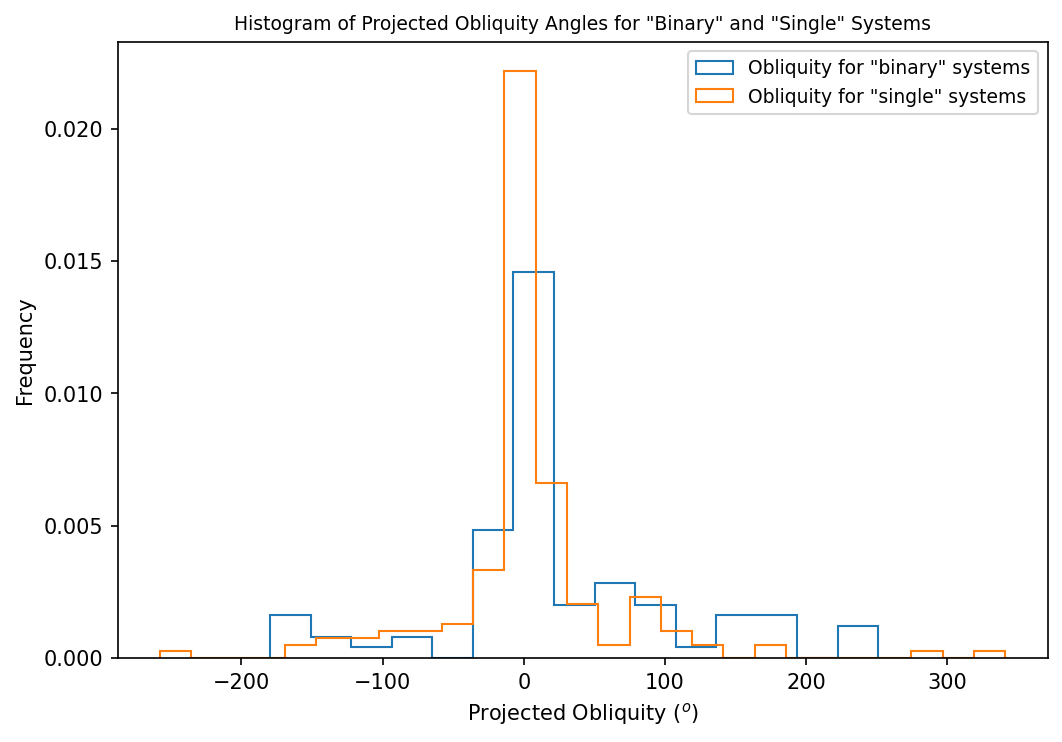

In [12]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.hist(binary_sys_ruwe['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.hist(single_sys_ruwe['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.title('Histogram of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('Frequency');
plt.legend(['Obliquity for "binary" systems', 'Obliquity for "single" systems'], fontsize=9, loc=1);

plt.show()

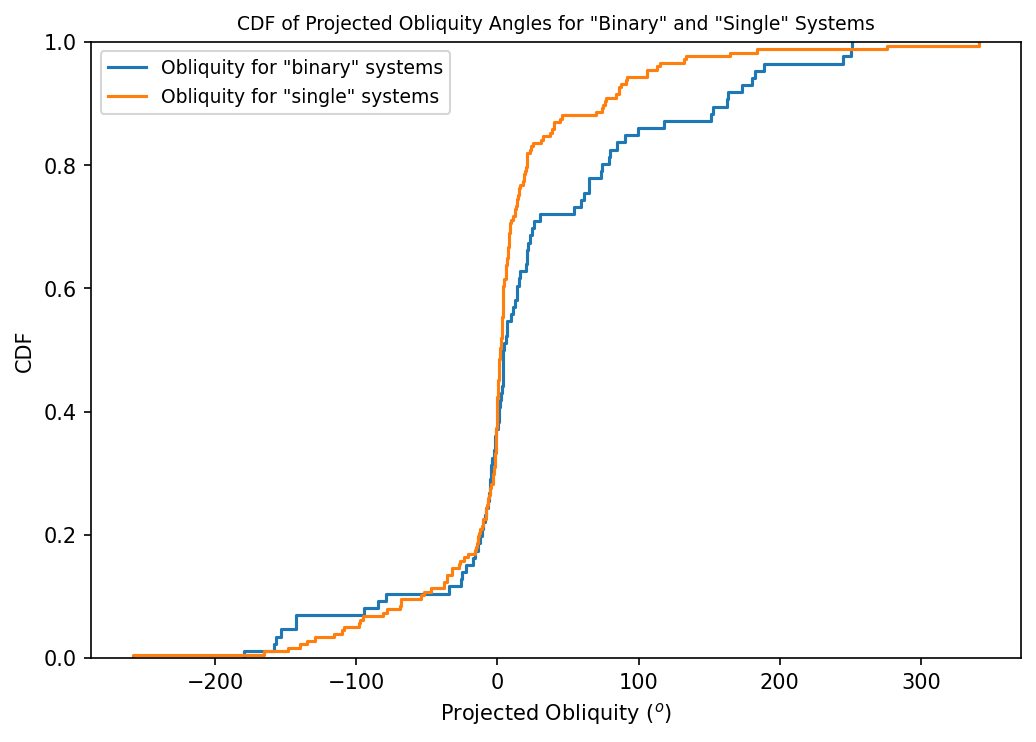

In [13]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.ecdf(binary_sys_ruwe['pl_projobliq']);
plt.ecdf(single_sys_ruwe['pl_projobliq']);
plt.title('CDF of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('CDF');
plt.legend(['Obliquity for "binary" systems', 'Obliquity for "single" systems'], fontsize=9, loc=2);

plt.show()

In [14]:
# Calculating D and p-value for the 2-sample K-S test on the two datasets
# ('binary_sys' vs. 'single_sys')
ks_d, ks_p = stats.kstest(binary_sys_ruwe['pl_projobliq'], single_sys_ruwe['pl_projobliq'])
print(f'K-S D, p-value: {ks_d:0.4f} {ks_p:0.4%}')

K-S D, p-value: 0.1631 7.9869%


In [15]:
# Calculating the D and p-value for k-sample Anderson-Darling (A-D) test
#  on the two datasets ('binary_sys' vs. 'single_sys')
ad = stats.anderson_ksamp([binary_sys_ruwe['pl_projobliq'], single_sys_ruwe['pl_projobliq']], variant='midrank', method=stats.PermutationMethod());
print(f'A-D statistics and p-value: {ad.statistic:0.4f} {ad.pvalue:0.4%}')


A-D statistics and p-value: 2.5091 3.3600%


#### Correlation Testing

In this section we would like to examine whether projected obliquity data is correlated to the RUWE data.

In [21]:
# Calculating Pearson r statistic
all_proj_obliq = table.vstack([single_sys_ruwe, binary_sys_ruwe])
pearson_r, pearson_p = stats.pearsonr(binary_sys_ruwe['pl_projobliq'], binary_sys_ruwe['ruwe'])
print(f'The Pearson r statistics is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')

# Calculating Spearman rho statistic
spearman_rho, spearman_p = stats.spearmanr(binary_sys_ruwe['pl_projobliq'], binary_sys_ruwe['ruwe'])
print(f'The Spearman rho statistics is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}')

The Pearson r statistics is 0.0051 with a p-value of 0.9629
The Spearman rho statistics is -0.1051 with a p-value of 0.3355
